#### MAI202 - Assignment2 -# Weather Forecasting with Sequence Models
##### Monireh Eshghinezhad

In [2]:
import importlib.util
if importlib.util.find_spec("torchmetrics") is None:
    %pip install -q torchmetrics

import sys, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchmetrics
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device: use a GPU/accelerator if available 
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")


Using device: cpu


### 1. Load & Explore the Dataset

In [7]:
df = pd.read_csv("weather_prediction_dataset.csv")
# The DATE column is an integer like 20000101 (YYYYMMDD) -> parse to real dates
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.set_index("DATE").sort_index()
dgf= df.drop_duplicates
print(f"Dataset shape: {df.shape}")
print(f"{len(df)} daily records from {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")


Dataset shape: (3654, 164)
3654 daily records from 2000-01-01 to 2010-01-01
Missing values: 0


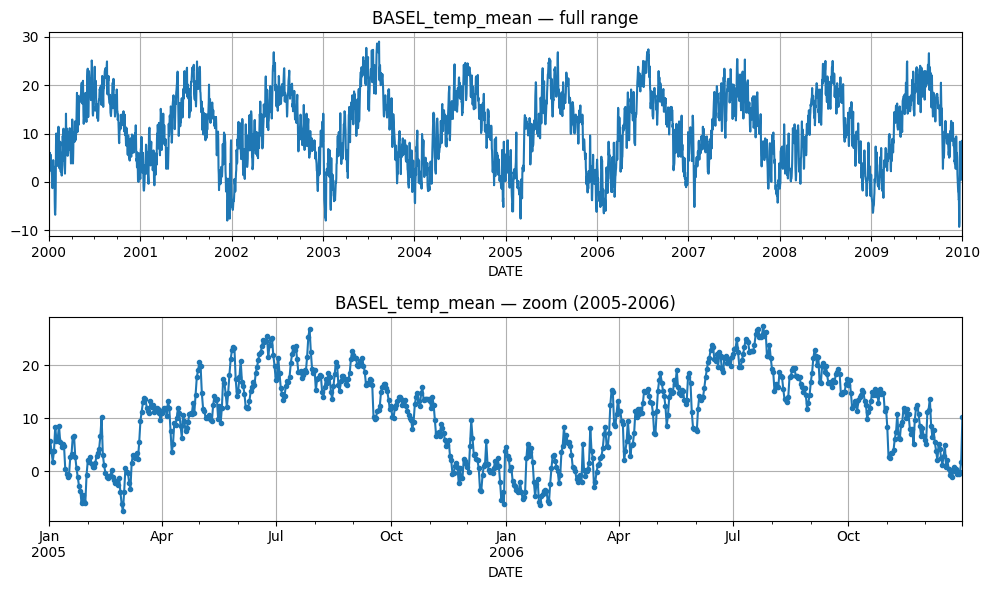

In [8]:
df["BASEL_temp_mean"].describe()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
df["BASEL_temp_mean"].plot(ax=axes[0], grid=True, title="BASEL_temp_mean — full range")
df["BASEL_temp_mean"].loc["2005-01":"2006-12"].plot(ax=axes[1], grid=True, marker=".",
                                                     title="BASEL_temp_mean — zoom (2005-2006)")
plt.tight_layout()
plt.show()

 #### Scenario 1: Single-step (14 → 1) 
 Feature: BASEL_temp_mean               
 Slide a 14-day window, predict the next 1 day.

### 2. Prepare the Dataset for Scenario 1

In [ ]:
# 2.1  70/30 split, with a validation holdout carved from the 70% ---
n = len(df)
test_start = int(n * 0.70)
train_val_df = df.iloc[:test_start]
test_df = df.iloc[test_start:]

# carve validation out of the train_val portion (e.g. last 15% of it), still chronological
val_start = int(len(train_val_df) * 0.85)
train_df = train_val_df.iloc[:val_start]
val_df = train_val_df.iloc[val_start:]

print(f"train: {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} rows)")
print(f"val:   {val_df.index.min().date()} -> {val_df.index.max().date()}  ({len(val_df)} rows)")
print(f"test:  {test_df.index.min().date()} -> {test_df.index.max().date()}  ({len(test_df)} rows)")

train: 2000-01-01 -> 2005-12-12  (2173 rows)
val:   2005-12-13 -> 2006-12-31  (384 rows)
test:  2007-01-01 -> 2010-01-01  (1097 rows)


In [10]:
# 2.2 Standardize using TRAIN statistics only 
feature_cols_s1 = ["BASEL_temp_mean"]

train_mean = train_df[feature_cols_s1].mean()
train_std = train_df[feature_cols_s1].std()

def standardize(frame):
    return (frame[feature_cols_s1] - train_mean) / train_std

train_s1 = torch.FloatTensor(standardize(train_df).values)
val_s1   = torch.FloatTensor(standardize(val_df).values)
test_s1  = torch.FloatTensor(standardize(test_df).values)

train_s1.shape, val_s1.shape, test_s1.shape


(torch.Size([2173, 1]), torch.Size([384, 1]), torch.Size([1097, 1]))

In [11]:
#  2.3 Base sliding-window Dataset (generalizes the lab's TimeSeriesDataset with a `horizon` arg) ---
class TimeSeriesDataset(Dataset):
    """
    series: FloatTensor of shape (T, num_columns), already standardized
    window_length: number of past steps the model sees
    horizon: number of future steps to predict (>=1)
    """
    def __init__(self, series, window_length, horizon):
        self.series = series
        self.window_length = window_length
        self.horizon = horizon

    def __len__(self):
        return len(self.series) - self.window_length - self.horizon + 1

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length            # 1st index after the window
        window = self.series[idx: end]             # (window_length, num_columns)
        target = self.series[end: end + self.horizon]  # (horizon, num_columns)
        return window, target


In [13]:
# --- 2.4 Scenario-1-specific subclass ---
class Scenario1Dataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        target = target.reshape(-1)   # (horizon=1, 1 col) -> flat vector shape (1,)
        return window, target

WINDOW_LENGTH = 14
HORIZON = 1

s1_train_set = Scenario1Dataset(train_s1, WINDOW_LENGTH, HORIZON)
s1_val_set   = Scenario1Dataset(val_s1,   WINDOW_LENGTH, HORIZON)
s1_test_set  = Scenario1Dataset(test_s1,  WINDOW_LENGTH, HORIZON)

BATCH_SIZE = 32
s1_train_loader = DataLoader(s1_train_set, batch_size=BATCH_SIZE, shuffle=True)
s1_val_loader   = DataLoader(s1_val_set,   batch_size=BATCH_SIZE)
s1_test_loader  = DataLoader(s1_test_set,  batch_size=BATCH_SIZE)

# Sanity check the shapes before building any model
xb, yb = next(iter(s1_train_loader))
print("window batch shape:", xb.shape)   # expect (batch, 14, 1)
print("target batch shape:", yb.shape)   # expect (batch, 1)


window batch shape: torch.Size([32, 14, 1])
target batch shape: torch.Size([32, 1])


### 3. Build & Train the Models (S1-a to S1-d)


In [14]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate_mae(model, loader):
    model.eval()
    total_abs_err, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        total_abs_err += (y_pred - y).abs().sum().item()
        n += y.numel()
    return total_abs_err / n


def train_and_evaluate(model, train_loader, val_loader, test_loader,
                        lr=1e-3, n_epochs=20, model_name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            # gradient clipping: standard/appropriate practice for RNNs, guards against exploding grads
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        val_mae = evaluate_mae(model, val_loader)
        print(f"[{model_name}] epoch {epoch+1:>2}/{n_epochs} — val MAE (standardized units): {val_mae:.4f}")

    training_time = time.time() - start
    test_mae = evaluate_mae(model, test_loader)

    return {
        "model": model_name,
        "params": count_params(model),
        "training_time_sec": round(training_time, 2),
        "val_mae": round(val_mae, 4),
        "test_mae": round(test_mae, 4),
    }


results_s1 = []  # collect one dict per model here

### S1-a — Simple RNN

In [15]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])   # many-to-one: only last step's hidden state


torch.manual_seed(SEED)
s1a_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1a_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-a SimpleRNN")
results_s1.append(res)
res


[S1-a SimpleRNN] epoch  1/20 — val MAE (standardized units): 0.2323
[S1-a SimpleRNN] epoch  2/20 — val MAE (standardized units): 0.2440
[S1-a SimpleRNN] epoch  3/20 — val MAE (standardized units): 0.2295
[S1-a SimpleRNN] epoch  4/20 — val MAE (standardized units): 0.2259
[S1-a SimpleRNN] epoch  5/20 — val MAE (standardized units): 0.2265
[S1-a SimpleRNN] epoch  6/20 — val MAE (standardized units): 0.2217
[S1-a SimpleRNN] epoch  7/20 — val MAE (standardized units): 0.2273
[S1-a SimpleRNN] epoch  8/20 — val MAE (standardized units): 0.2378
[S1-a SimpleRNN] epoch  9/20 — val MAE (standardized units): 0.2256
[S1-a SimpleRNN] epoch 10/20 — val MAE (standardized units): 0.2309
[S1-a SimpleRNN] epoch 11/20 — val MAE (standardized units): 0.2262
[S1-a SimpleRNN] epoch 12/20 — val MAE (standardized units): 0.2612
[S1-a SimpleRNN] epoch 13/20 — val MAE (standardized units): 0.2283
[S1-a SimpleRNN] epoch 14/20 — val MAE (standardized units): 0.2336
[S1-a SimpleRNN] epoch 15/20 — val MAE (standard

{'model': 'S1-a SimpleRNN',
 'params': 1153,
 'training_time_sec': 3.84,
 'val_mae': 0.2269,
 'test_mae': 0.2194}

### S1-b — Deeper RNN

In [ ]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
# dropout between stacked recurrent layers is a standard regularization practice for deeper RNNs
s1b_model = DeepRnnModel(input_size=1, hidden_size=32, output_size=1, num_layers=3, dropout=0.1)
res = train_and_evaluate(s1b_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-b DeepRNN")
results_s1.append(res)
res

### S1-c — LSTM

In [ ]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s1c_model = LstmModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1c_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-c LSTM")
results_s1.append(res)
res

### S1-d — GRU

In [ ]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s1d_model = GruModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1d_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-d GRU")
results_s1.append(res)
res
